<a href="https://colab.research.google.com/github/bishowAd/plant-disease-classifier/blob/main/Plant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls "/content/drive/My Drive"   # This command is used in a Google Colab notebook to list the files and folders stored in your Google Drive

 1192b716-d8ee-4c67-8f51-97246ea3b8f5.jpg
 20231229_115426.jpg
 33d0570b-8ef1-449f-86c7-525c53d71f13.jpg
 426dd535-4044-4c34-b440-aa2f787acc24.jpg
 4f2cf4ca-6e9d-47d8-9426-06330e230c97.jpg
 5a2b0119-d6af-44d5-a7cb-04e61549c29f.jpg
 5b8733f2-c779-4b90-817b-e6c9063cd05a.jpg
 60643942-15eb-410a-b98c-87b00c613706.jpg
 7c22dfe9-bae2-4c57-a640-ac7308a78b77.jpg
 81c3ef20-86e6-48bf-9ecb-6ceda3d23e39.jpg
 8bc13092-b724-4cd3-9ba4-cc735becfb5a.jpg
 927500e5-8595-49ba-893b-8ea9a2e4a014.jpg
 att.NA7UcYPPN7irIeEj1auFHvUSiLBpq9mLQUkqbLgnvMc.pdf
 Azure.gdoc
 b18b9b97-cae9-4d27-abb1-ed899dccc086.jpg
'Bishow Adhikari.docx.pdf'
 Bishow_DataScience_Course.gsheet
'BLANK consultation form (1).docx'
'BLANK consultation form (2).docx'
'BLANK consultation form.docx'
'C0 (1).zip'
 C0.zip
 c6a290f5-ce69-42bb-a6f6-6b9efd62cb63.jpg
 card.PDF
 Carrer_Resume-2026.gdoc
 Carrer_Resume-2026.pdf
 cb9423b5-1745-4be4-8ca4-8e07a339df4e.jpg
 ce51a8b5-e2a5-4230-9b87-4e666e9fe4a4.jpg
'Class notes.gdoc'
'CMPS161ClassNotesChap0

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread
from matplotlib.image import imread #he purpose of the imread function is to read an image file from a specified path and convert it into a NumPy array.
import cv2
import random
import os
from os import listdir #: This function returns a list containing the names of all the entries (files and subdirectories) in a specified directory.
from PIL import Image #his imports the Image class and related functions (like Image.open(), Image.new(), etc.) that allow you to load, create, manipulate, and save images in various formats (JPEG, PNG, etc.).
from sklearn.preprocessing import  label_binarize, LabelBinarizer
from keras.preprocessing import image
from keras.preprocessing.image import img_to_array, array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dropout, Dense
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical


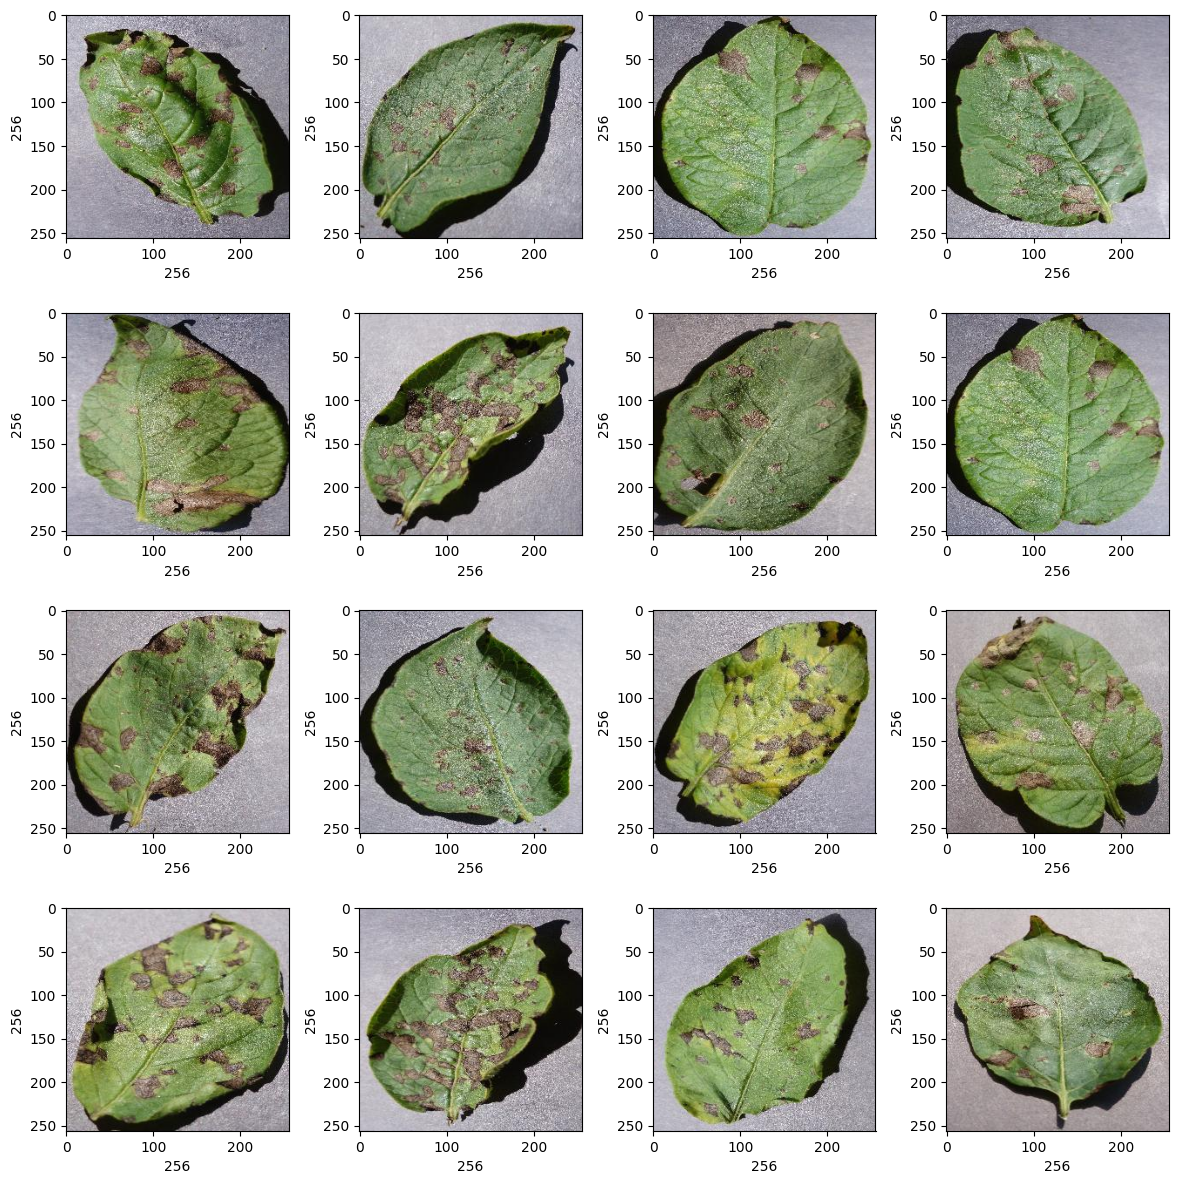

In [5]:
plt.figure(figsize=(12,12))
path = "/content/drive/My Drive/Plant_image/Potato___Early_blight"
for i in range(1,17):
  plt.subplot(4,4,i)# Defines a grid for the figure that has 4 rows and 4 columns (4x4 grid).
  plt.tight_layout()  #This command is called within the loop in each iteration. It automatically adjusts the parameters of the subplots (padding, spacing) so that labels, titles, and other elements do not overlap and fit cleanly within the figure area.
  rand_img=imread(path+'/'+random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize=10)
  plt.ylabel(rand_img.shape[0], fontsize=10)

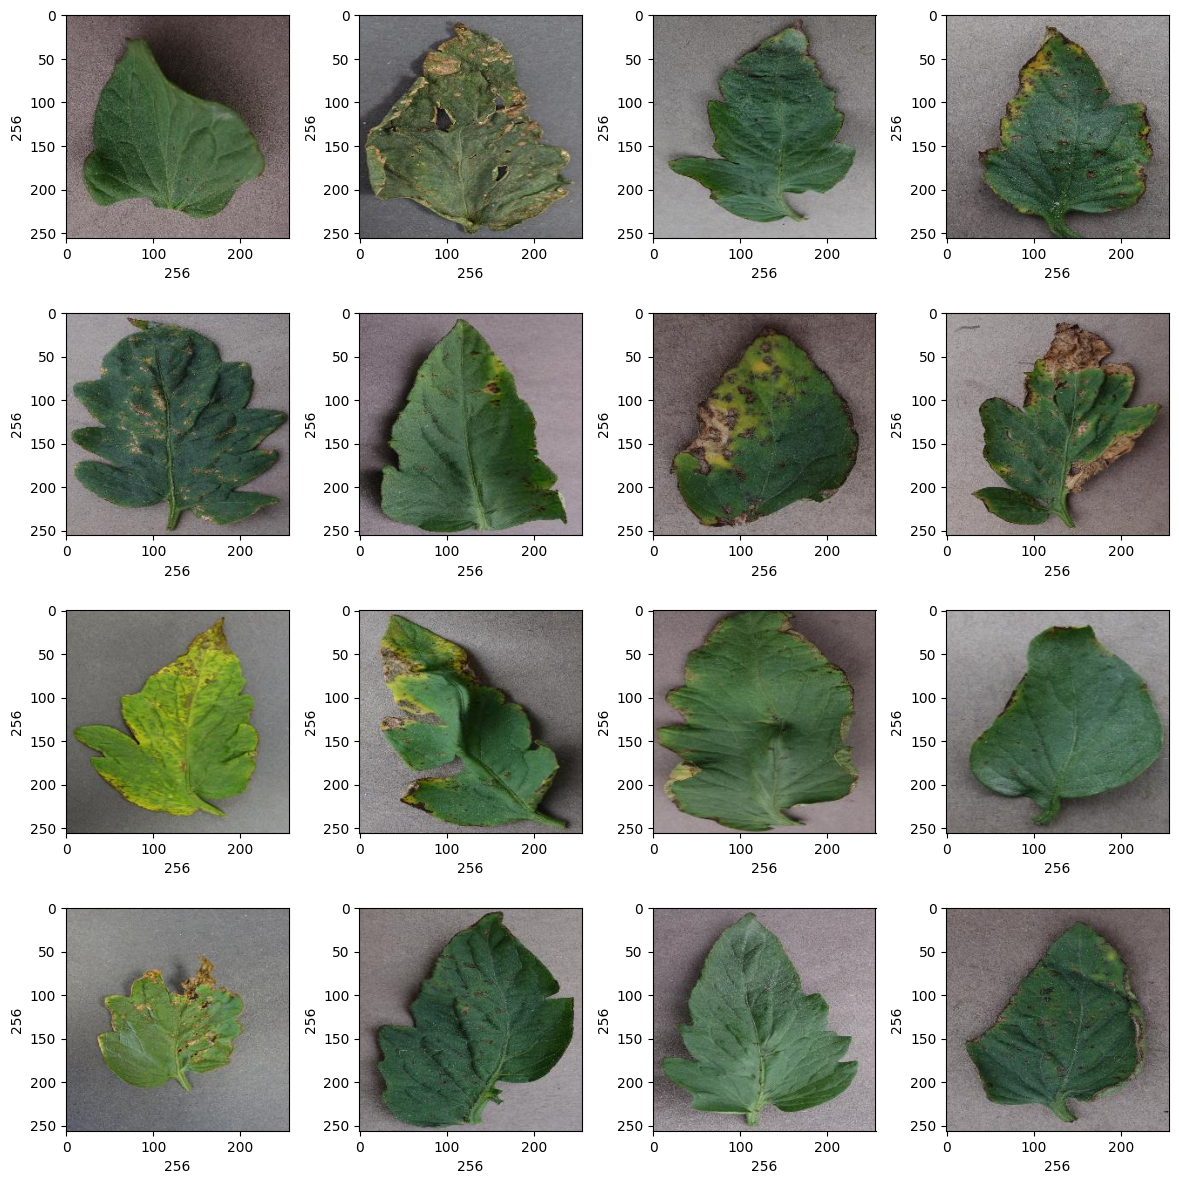

In [6]:
plt.figure(figsize=(12,12))
path = "/content/drive/My Drive/Plant_image/Tomato_Bacterial_Spot"
for i in range(1,17):
  plt.subplot(4,4,i)# Defines a grid for the figure that has 4 rows and 4 columns (4x4 grid).
  plt.tight_layout()  #This command is called within the loop in each iteration. It automatically adjusts the parameters of the subplots (padding, spacing) so that labels, titles, and other elements do not overlap and fit cleanly within the figure area.
  rand_img=imread(path+'/'+random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize=10)
  plt.ylabel(rand_img.shape[0], fontsize=10)

# Converting image into numpy array

In [7]:
# Function ( reusable code of array )
def convert_image_to_array(image_dir):
  try:
    image = cv2.imread(image_dir)
    if image is not None:
      image = cv2.resize(image, (256,256))
      return img_to_array(image)
    else:
      return np.array([])
  except Exception as e:
    print(f"Error : {e}")
    return None


In [8]:
# Setting up empty containers and label mappings before the loop that will fill them with images and their corresponding disease labels.
dir = "/content/drive/My Drive/Plant_image"
root_dir= listdir(dir)  #  lists all subfolders inside it, gives you
image_list, label_list = [], []  # two empty list to store will stored the image converted into array and numeric values of image conerted intp array
all_labels = ['Corn_Rust', 'Potato___Early_blight', 'Tomato_Bacterial_Spot']
binary_labels = [0,1,2]
temp = -1

#Walking through every folder, reads every image, and pairs each image with its disease label number.
for directory in root_dir:
  Plant_image_list= listdir(f"{dir}/{directory}")
  temp = temp + 1
  for files in Plant_image_list:
    image_path = f"{dir}/{directory}/{files}"
    image_list.append(convert_image_to_array(image_path))
    label_list.append(binary_labels[temp])


In [9]:
label_count = pd.DataFrame(label_list).value_counts()
label_count.head()

,count
0,
0,300
1,300
2,300


In [10]:
image_list[1].shape
image_list[2].shape
image_list[0].shape

(256, 256, 3)

In [11]:
label_list = np.array(label_list)
label_list.shape
# Length of all the label list


(900,)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(image_list, label_list, test_size=0.2, random_state=10)

In [13]:
x_train = np.array(x_train, dtype=np.float16) / 255.0 # converting  python list of array  into single numpy array.  # Normalizing.
x_test = np.array(x_test, dtype=np.float16) / 255.0
x_train = x_train.reshape( -1, 256,256,3)
x_test = x_test.reshape( -1, 256,256,3)

In [14]:
y_train = to_categorical(y_train) #. What to_categorical() does ??? Ans : Conevert into one-hot encoding vectors. For ecample [1,0,2] to [ 001, 0001, 010 ]
y_test = to_categorical(y_test)

In [15]:
model = Sequential()
model.add(Conv2D(32, (3,3), padding = "same" ,input_shape=(256,256,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(3,3)))
model.add(Conv2D(64, (3,3), padding = "same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 85, 85, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 112896)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     7,225,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,244,995 (27.64 MB)

 Trainable params: 7,244,995 (27.64 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [17]:
# splitting the data into train  and valdition state .
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=10)

In [18]:
epochs  = 10
batch_size = 128
history = model.fit(x_train, y_train, batch_size= batch_size, epochs=epochs, validation_data=(x_val, y_val))
#



Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 9s/step - accuracy: 0.3819 - loss: 4.1768 - val_accuracy: 0.6319 - val_loss: 0.9758
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step - accuracy: 0.6632 - loss: 0.7394 - val_accuracy: 0.6389 - val_loss: 0.6205
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - accuracy: 0.7153 - loss: 0.5117 - val_accuracy: 0.9583 - val_loss: 0.3220
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 8s/step - accuracy: 0.9670 - loss: 0.1979 - val_accuracy: 0.9861 - val_loss: 0.0852
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step - accuracy: 0.9809 - loss: 0.0791 - val_accuracy: 0.9861 - val_loss: 0.0379
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.9878 - loss: 0.0355 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.9983 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0137
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.9983 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 9/

In [24]:
model.save('/content/drive/My Drive/Plant_image/model.keras')

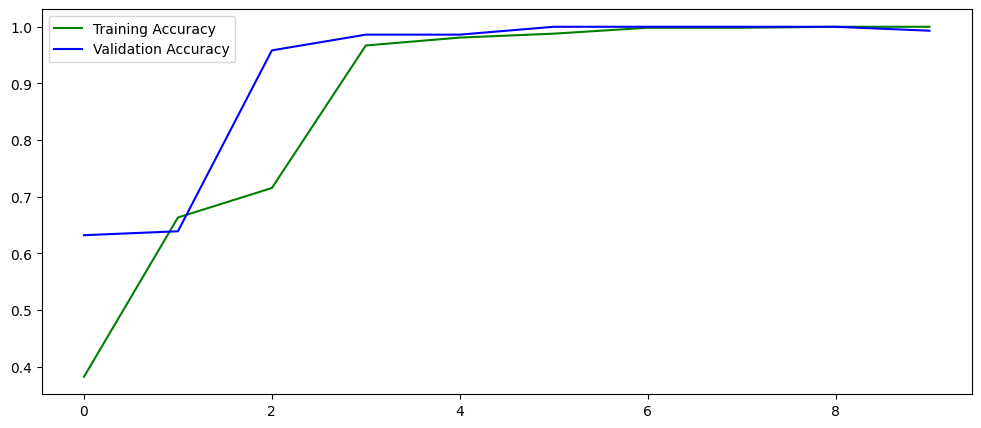

In [25]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], color='green', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.legend()
plt.show()

In [26]:
scores=model.evaluate(x_test, y_test)
print(f"Test Accuracy: {scores[1]*100}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step - accuracy: 0.9944 - loss: 0.0187
Test Accuracy: 99.44444298744202


In [27]:
y_pred = model.predict(x_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 541ms/step


In [30]:
img = array_to_img(x_test[10])

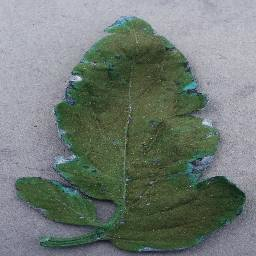

In [31]:
img

In [32]:
print("Orginal :",all_labels[np.argmax(y_test[10])])
print("Predicted :",all_labels[np.argmax(y_pred[10])])

Orginal : Potato___Early_blight
Predicted : Potato___Early_blight
